# Big Data Midterm Exam

**Student:** Anush Khachatryan
**Course:** Big Data
**Dataset:** Instacart Market Basket Analysis
**Date:** 10.05.2026

In [1]:
# Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    sum,
    when,
    count,
    countDistinct,
    avg,
    desc,
    lower,
    trim,
    regexp_replace,
    row_number,
    broadcast,
    max,
    format_string
)

from pyspark.sql.window import Window

# Python libraries
import pandas as pd
import matplotlib.pyplot as plt
import time

In [2]:
spark = (
    SparkSession.builder
    .appName("InstacartMidterm")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.1.1


# Instacart Market Basket Analysis

## 1. Data Loading and Initial Exploration

In [4]:
orders_path = "data/orders.csv"

products_path = "data/products.csv"

prior_path = "data/order_products__prior.csv"

train_path = "data/order_products__train.csv"

aisles_path = "data/aisles.csv"

departments_path = "data/departments.csv"

In [5]:
orders = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(orders_path)
)

products = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(products_path)
)

prior = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(prior_path)
)

train = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(train_path)
)

aisles = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(aisles_path)
)

departments = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(departments_path)
)

### Dataset Overview

In this section, we load and inspect all Instacart datasets to understand their structure, dimensions, and relationships before performing data cleaning and analytics.

In [6]:
print("Orders rows:", orders.count())
print("Products rows:", products.count())
print("Prior rows:", prior.count())
print("Train rows:", train.count())
print("Aisles rows:", aisles.count())
print("Departments rows:", departments.count())

Orders rows: 3421083
Products rows: 49688
Prior rows: 32434489
Train rows: 1384617
Aisles rows: 134
Departments rows: 21


### Schema Inspection

We inspect the schema of each dataset to verify data types, identify potential inconsistencies, and understand key columns used for joins and analytics.

In [7]:
orders.printSchema()

products.printSchema()

prior.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: integer (nullable = true)
 |-- order_hour_of_day: integer (nullable = true)
 |-- days_since_prior_order: double (nullable = true)

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: string (nullable = true)
 |-- department_id: string (nullable = true)

root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)



### Sample Records

A small preview helps verify that the datasets were loaded correctly and that the values match the expected Instacart structure.

In [8]:
orders.show(5, truncate=False)
products.show(5, truncate=False)
prior.show(5, truncate=False)

+--------+-------+--------+------------+---------+-----------------+----------------------+
|order_id|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior_order|
+--------+-------+--------+------------+---------+-----------------+----------------------+
|2539329 |1      |prior   |1           |2        |8                |NULL                  |
|2398795 |1      |prior   |2           |3        |7                |15.0                  |
|473747  |1      |prior   |3           |3        |12               |21.0                  |
|2254736 |1      |prior   |4           |4        |7                |29.0                  |
|431534  |1      |prior   |5           |4        |15               |28.0                  |
+--------+-------+--------+------------+---------+-----------------+----------------------+
only showing top 5 rows
+----------+-----------------------------------------------------------------+--------+-------------+
|product_id|product_name                      

### Data Type Corrections

During schema inspection, we observed that `aisle_id` and `department_id` were loaded as string columns instead of integers.

This inconsistency may negatively affect joins, filtering performance, and aggregation logic. Therefore, we explicitly cast these columns to integer type.

In [9]:
products = (
    products
    .withColumn("aisle_id", col("aisle_id").cast("int"))
    .withColumn("department_id", col("department_id").cast("int"))
)

In [10]:
products.printSchema()

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: integer (nullable = true)
 |-- department_id: integer (nullable = true)



The analysis primarily focuses on the `prior` dataset because it represents historical user purchasing behavior and contains significantly larger transactional volume compared to the train dataset.

This makes it more suitable for behavioral pattern analysis and reorder-frequency analytics.

## 2. Data Quality Analysis

The goal of this section is to identify non-obvious data quality issues that may bias analytics results or introduce incorrect interpretations.

We focus on:
- Missing values
- Duplicate records
- Invalid value ranges
- Inconsistent ordering behavior
- Data type inconsistencies

### CSV Parsing Issue in Products Table

During the initial schema inference process, there was a potential risk of CSV parsing artifacts in the `products` table, particularly because product names may contain punctuation or formatting patterns that can confuse automatic schema inference.

To avoid possible parsing inconsistencies, the dataset was reloaded using explicit validation and schema checks. After validation, no malformed product rows were detected (`0 bad rows`).

This suggests that the issue was related to cautious parsing validation rather than confirmed corruption in the dataset itself.

In [11]:
products_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("quote", '"')
    .option("escape", '"')
    .option("multiLine", True)
    .csv(products_path)
)

products_raw.printSchema()
products_raw.show(5, truncate=False)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: string (nullable = true)
 |-- department_id: string (nullable = true)

+----------+-----------------------------------------------------------------+--------+-------------+
|product_id|product_name                                                     |aisle_id|department_id|
+----------+-----------------------------------------------------------------+--------+-------------+
|1         |Chocolate Sandwich Cookies                                       |61      |19           |
|2         |All-Seasons Salt                                                 |104     |13           |
|3         |Robust Golden Unsweetened Oolong Tea                             |94      |7            |
|4         |Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce|38      |1            |
|5         |Green Chile Anytime Sauce                                        |5       |13           |
+------

In [12]:
bad_products = products_raw.filter(
    col("aisle_id").cast("int").isNull() |
    col("department_id").cast("int").isNull()
)

bad_products.show(20, truncate=False)

print("Bad product rows:", bad_products.count())

+----------+------------+--------+-------------+
|product_id|product_name|aisle_id|department_id|
+----------+------------+--------+-------------+
+----------+------------+--------+-------------+

Bad product rows: 0


### Final Type Standardization

After validating that all identifier columns contain valid numeric values, we safely cast them to integer type for efficient joins and aggregations.

In [13]:
products = (
    products_raw
    .withColumn("product_id", col("product_id").cast("int"))
    .withColumn("aisle_id", col("aisle_id").cast("int"))
    .withColumn("department_id", col("department_id").cast("int"))
)

products.printSchema()

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: integer (nullable = true)
 |-- department_id: integer (nullable = true)



### Missing Value Analysis

Missing values can bias the analysis if they affect ordering behavior, product metadata, or user activity patterns. We quantify missing values for the core tables before deciding whether they require fixing or can be explained by the dataset logic.

In [14]:
orders.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in orders.columns
]).show()

products.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in products.columns
]).show()

prior.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in prior.columns
]).show()

+--------+-------+--------+------------+---------+-----------------+----------------------+
|order_id|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior_order|
+--------+-------+--------+------------+---------+-----------------+----------------------+
|       0|      0|       0|           0|        0|                0|                206209|
+--------+-------+--------+------------+---------+-----------------+----------------------+

+----------+------------+--------+-------------+
|product_id|product_name|aisle_id|department_id|
+----------+------------+--------+-------------+
|         0|           0|       0|            0|
+----------+------------+--------+-------------+

+--------+----------+-----------------+---------+
|order_id|product_id|add_to_cart_order|reordered|
+--------+----------+-----------------+---------+
|       0|         0|                0|        0|
+--------+----------+-----------------+---------+



### Missing Value Findings

The analysis shows that the only significant missing values appear in `days_since_prior_order`.

This is expected behavior rather than a data corruption issue. The missing values correspond to users placing their first recorded order, where no previous order exists.

Impact on analytics:
- Missing values may bias temporal analyses if treated incorrectly.
- Replacing them with 0 could falsely imply immediate reordering behavior.

Proposed handling:
- Keep NULL values during exploratory analysis.
- When needed for modeling or aggregation, use a business-aware replacement strategy rather than blind imputation.

### Duplicate Record Analysis

Duplicate records may artificially inflate product popularity, reorder frequency, or user activity metrics. Therefore, duplicates must be investigated carefully rather than removed blindly.

In [15]:
duplicate_prior = (
    prior
    .groupBy("order_id", "product_id")
    .agg(count("*").alias("count"))
    .filter(col("count") > 1)
)

print("Duplicate order-product pairs:", duplicate_prior.count())

duplicate_prior.show(10)

Duplicate order-product pairs: 0
+--------+----------+-----+
|order_id|product_id|count|
+--------+----------+-----+
+--------+----------+-----+



In [16]:
duplicate_product_names = (
    products
    .groupBy("product_name")
    .agg(countDistinct("product_id").alias("num_product_ids"))
    .filter(col("num_product_ids") > 1)
)

duplicate_product_names.show(10, truncate=False)

+------------+---------------+
|product_name|num_product_ids|
+------------+---------------+
+------------+---------------+



We also checked whether multiple product IDs share the same product name.

No duplicated product names linked to different product IDs were detected in the dataset, which reduces the risk of ambiguity during normalization and grouping operations.

### Duplicate Findings

No duplicate `(order_id, product_id)` pairs were detected in the prior orders dataset.

This is important because:
- Product frequency calculations remain reliable.
- Joins based on `order_id` and `product_id` will not artificially inflate counts.
- Blind duplicate removal is unnecessary and could remove legitimate purchasing behavior if applied incorrectly.

Therefore, no duplicate rows were removed from the transactional dataset.

### Invalid Value Range Analysis

We validate whether key columns contain logically impossible values that may indicate corrupted records or ingestion issues.

In [17]:
print(
    "Invalid reordered values:",
    prior.filter(~col("reordered").isin(0, 1)).count()
)

print(
    "Invalid order_hour_of_day values:",
    orders.filter(
        (col("order_hour_of_day") < 0) |
        (col("order_hour_of_day") > 23)
    ).count()
)

print(
    "Invalid order_dow values:",
    orders.filter(
        (col("order_dow") < 0) |
        (col("order_dow") > 6)
    ).count()
)

Invalid reordered values: 0
Invalid order_hour_of_day values: 0
Invalid order_dow values: 0


In [18]:
orders.select("eval_set").distinct().show()

+--------+
|eval_set|
+--------+
|   prior|
|    test|
|   train|
+--------+



In [19]:
# days_since_prior_order > 30 check
print(
    "Orders with days_since_prior_order > 30:",
    orders.filter(col("days_since_prior_order") > 30).count()
)

# add_to_cart_order gap check
cart_gaps = (
    prior
    .groupBy("order_id")
    .agg(
        count("*").alias("item_count"),
        max("add_to_cart_order").alias("max_cart")
    )
    .filter(col("max_cart") != col("item_count"))
)
print("Orders with cart order gaps:", cart_gaps.count())

Orders with days_since_prior_order > 30: 0
Orders with cart order gaps: 0


days_since_prior_order values were validated against the dataset specification (max 30 days). No violations were detected. add_to_cart_order sequences were checked for gaps within each order. No missing line items were found. Both checks confirm that the transactional data is internally consistent beyond the obvious quality checks.

In [54]:
# 30-day cap analysis
days_dist = (
    orders
    .filter(col("days_since_prior_order").isNotNull())
    .groupBy("days_since_prior_order")
    .count()
    .orderBy(desc("count"))
    .limit(5)
)
days_dist.show()

+----------------------+------+
|days_since_prior_order| count|
+----------------------+------+
|                  30.0|369323|
|                   7.0|320608|
|                   6.0|240013|
|                   4.0|221696|
|                   3.0|217005|
+----------------------+------+



The value 30.0 appears 369,323 times — more frequently than any other value including the weekly cycle peak of 7 days (320,608 occurrences). This confirms that days_since_prior_order is capped at 30 in the dataset. All reorder gaps of 30 or more days are recorded as exactly 30, making long-gap users indistinguishable. This is a non-obvious data quality limitation that can bias temporal gap analysis and reorder frequency metrics.

The `eval_set` column was also validated.

Only the expected dataset split labels were detected:
- `prior`
- `train`
- `test`

No malformed or unexpected partition labels were found.

### Range Validation Findings

No logically invalid values were detected in the key behavioral columns:
- `reordered` contains only binary values (0 or 1)
- `order_hour_of_day` remains within the valid 24-hour range
- `order_dow` remains within the weekly range (0–6)

This suggests that the transactional logs are internally consistent and suitable for downstream analytics.

### Ordering Consistency Analysis

For each user, order numbers should increase sequentially over time. Missing or inconsistent order sequences may indicate incomplete transaction history or ingestion issues.

In [20]:
order_consistency = (
    orders
    .groupBy("user_id")
    .agg(
        max("order_number").alias("max_order_number"),
        countDistinct("order_number").alias("distinct_order_numbers")
    )
    .filter(col("max_order_number") != col("distinct_order_numbers"))
)

print("Users with inconsistent order sequences:")
print(order_consistency.count())

Users with inconsistent order sequences:
0


### Full Dataset Validation

Before continuing the analysis, we perform additional validation checks to ensure that the datasets were parsed correctly and do not contain hidden formatting or schema issues.

In [21]:
print("Orders columns:", orders.columns)
print("Products columns:", products.columns)
print("Prior columns:", prior.columns)

print("\nDistinct product_id nulls:",
      products.filter(col("product_id").isNull()).count())

print("Distinct aisle_id nulls:",
      products.filter(col("aisle_id").isNull()).count())

print("Distinct department_id nulls:",
      products.filter(col("department_id").isNull()).count())

print("\nProducts with suspicious IDs:")

products.filter(
    (col("product_id") <= 0) |
    (col("aisle_id") <= 0) |
    (col("department_id") <= 0)
).show(20, truncate=False)

Orders columns: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
Products columns: ['product_id', 'product_name', 'aisle_id', 'department_id']
Prior columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered']

Distinct product_id nulls: 0
Distinct aisle_id nulls: 0
Distinct department_id nulls: 0

Products with suspicious IDs:
+----------+------------+--------+-------------+
|product_id|product_name|aisle_id|department_id|
+----------+------------+--------+-------------+
+----------+------------+--------+-------------+



In [22]:
products.select("product_name").show(20, truncate=False)

+-----------------------------------------------------------------+
|product_name                                                     |
+-----------------------------------------------------------------+
|Chocolate Sandwich Cookies                                       |
|All-Seasons Salt                                                 |
|Robust Golden Unsweetened Oolong Tea                             |
|Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce|
|Green Chile Anytime Sauce                                        |
|Dry Nose Oil                                                     |
|Pure Coconut Water With Orange                                   |
|Cut Russet Potatoes Steam N' Mash                                |
|Light Strawberry Blueberry Yogurt                                |
|Sparkling Orange Juice & Prickly Pear Beverage                   |
|Peach Mango Juice                                                |
|Chocolate Fudge Layer Cake                     

### Final Data Validation Comment

After additional validation, the dataset appears to be correctly parsed and internally consistent. The earlier schema/parsing issue in the products table was resolved by reloading the CSV with explicit parsing options and validating the identifier columns before casting them to integer type.

Final checks confirmed that:
- All expected columns are present.
- Product, aisle, and department IDs contain no missing or invalid values.
- Product names are correctly loaded and not split across columns.
- No duplicate `(order_id, product_id)` records were found.
- Behavioral fields such as `reordered`, `order_hour_of_day`, and `order_dow` contain valid values.

Therefore, the dataset is suitable for downstream joins, product-level analytics, and user behavior analysis after the applied preprocessing steps.

# 3. Data Manipulation, Joins, and Cleaning

This section combines transactional and product-level datasets into a unified analytical table.

Main objectives:
- Create a cleaned dataset for analysis
- Perform joins without introducing duplication artifacts
- Normalize product names
- Prepare the data for user-level behavioral analytics

### Join Logic and Duplication Prevention

The joins are performed using primary-to-foreign key relationships:

- `orders.order_id` , `prior.order_id`
- `products.product_id` , `prior.product_id`

These joins do not introduce artificial duplication because:
- Each `order_id` in the orders table is unique.
- Each row in the prior table represents one product within one order.
- Duplicate `(order_id, product_id)` pairs were previously validated and not detected.

Therefore, the resulting joined dataset preserves transactional granularity without inflating counts.

In [56]:
clean_prior = (
    prior
    .join(orders, on="order_id", how="inner")
    .join(products, on="product_id", how="inner")
)

clean_prior = clean_prior.withColumn(
    "normalized_product_name",
    trim(
        regexp_replace(
            lower(
                regexp_replace(
                    col("product_name"),
                    "[^a-zA-Z0-9 ]",
                    ""
                )
            ),
            "\\s+",
            " "
        )
    )
)

clean_prior.show(5, truncate=False)

+----------+--------+-----------------+---------+-------+--------+------------+---------+-----------------+----------------------+----------------------------------+--------+-------------+----------------------------------+
|product_id|order_id|add_to_cart_order|reordered|user_id|eval_set|order_number|order_dow|order_hour_of_day|days_since_prior_order|product_name                      |aisle_id|department_id|normalized_product_name           |
+----------+--------+-----------------+---------+-------+--------+------------+---------+-----------------+----------------------+----------------------------------+--------+-------------+----------------------------------+
|30597     |12      |1                |1        |152610 |prior   |22          |6        |8                |10.0                  |French Vanilla Coffee Creamer     |53      |16           |french vanilla coffee creamer     |
|15221     |12      |2                |1        |152610 |prior   |22          |6        |8              

In [58]:
clean_prior_exploration = clean_prior.withColumn(
    "product_subgroup",
    when(col("normalized_product_name").contains("banana"), "banana")
    .when(col("normalized_product_name").contains("milk"), "milk")
    .when(col("normalized_product_name").contains("water"), "water")
    .when(col("normalized_product_name").contains("yogurt"), "yogurt")
    .when(col("normalized_product_name").contains("bread"), "bread")
    .when(col("normalized_product_name").contains("chicken"), "chicken")
    .when(col("normalized_product_name").contains("cheese"), "cheese")
    .when(col("normalized_product_name").contains("coffee"), "coffee")
    .otherwise("other")
)

In [59]:
clean_prior_exploration.filter(col("product_subgroup") == "other") \
    .groupBy("product_name") \
    .count() \
    .orderBy(desc("count")) \
    .show(30, truncate=False)

+------------------------------------+------+
|product_name                        |count |
+------------------------------------+------+
|Organic Strawberries                |264683|
|Organic Baby Spinach                |241921|
|Organic Hass Avocado                |213584|
|Organic Avocado                     |176815|
|Large Lemon                         |152657|
|Strawberries                        |142951|
|Limes                               |140627|
|Organic Raspberries                 |137057|
|Organic Yellow Onion                |113426|
|Organic Garlic                      |109778|
|Organic Zucchini                    |104823|
|Organic Blueberries                 |100060|
|Cucumber Kirby                      |97315 |
|Organic Fuji Apple                  |89632 |
|Organic Lemon                       |87746 |
|Apple Honeycrisp Organic            |85020 |
|Organic Grape Tomatoes              |84255 |
|Seedless Red Grapes                 |82689 |
|Organic Cucumber                 

### Iterative exploration to identify top uncovered aisle groups

The following cells were used to inspect products and aisles that were still classified as `other`.
This iterative exploration helped identify the most frequent uncovered aisle groups and extend the final semantic subgroup mapping in a systematic way.

In [61]:
clean_prior_exploration.filter(col("product_subgroup") == "other") \
    .groupBy("aisle_id") \
    .count() \
    .orderBy(desc("count")) \
    .show(20)

+--------+-------+
|aisle_id|  count|
+--------+-------+
|      83|3413938|
|      24|2739802|
|     123|1735850|
|     107| 685715|
|     116| 519566|
|      31| 512716|
|      86| 452134|
|       3| 445437|
|      78| 412076|
|      37| 410344|
|      16| 377741|
|      96| 373173|
|     121| 373051|
|      67| 354835|
|      77| 351553|
|      17| 306711|
|     117| 298259|
|      81| 296104|
|      92| 290110|
|      88| 282409|
+--------+-------+
only showing top 20 rows


In [28]:
aisles.filter(col("aisle_id").isin(
    83, 24, 123, 107, 116, 31, 86, 3, 78, 37,
    16, 96, 121, 67, 77, 17, 117, 81, 92, 88
)).orderBy("aisle_id").show(20, truncate=False)

+--------+--------------------------+
|aisle_id|aisle                     |
+--------+--------------------------+
|3       |energy granola bars       |
|16      |fresh herbs               |
|17      |baking ingredients        |
|24      |fresh fruits              |
|31      |refrigerated              |
|37      |ice cream ice             |
|67      |fresh dips tapenades      |
|77      |soft drinks               |
|78      |crackers                  |
|81      |canned jarred vegetables  |
|83      |fresh vegetables          |
|86      |eggs                      |
|88      |spreads                   |
|92      |baby food formula         |
|96      |lunch meat                |
|107     |chips pretzels            |
|116     |frozen produce            |
|117     |nuts seeds dried fruit    |
|121     |cereal                    |
|123     |packaged vegetables fruits|
+--------+--------------------------+



In [62]:
clean_prior = clean_prior.withColumn(
    "product_subgroup",
    when(lower(col("product_name")).contains("banana"), "banana")
    .when(lower(col("product_name")).contains("milk"), "milk")
    .when(lower(col("product_name")).contains("yogurt"), "yogurt")
    .when(lower(col("product_name")).contains("bread"), "bread")
    .when(lower(col("product_name")).contains("coffee"), "coffee")
    .when(lower(col("product_name")).contains("cheese"), "cheese")
    .when(lower(col("product_name")).contains("chicken"), "chicken")
    .when(lower(col("product_name")).contains("water"), "water")
    # Aisle-based fallback
    .when(col("aisle_id") == 83, "fresh vegetables")
    .when(col("aisle_id") == 24, "fresh fruits")
    .when(col("aisle_id") == 123, "packaged vegetables fruits")
    .when(col("aisle_id") == 107, "chips pretzels")
    .when(col("aisle_id") == 116, "frozen produce")
    .when(col("aisle_id") == 31,  "refrigerated")
    .when(col("aisle_id") == 86,  "eggs")
    .when(col("aisle_id") == 3,   "energy granola bars")
    .when(col("aisle_id") == 78,  "crackers")
    .when(col("aisle_id") == 37,  "ice cream")
    .when(col("aisle_id") == 16,  "fresh herbs")
    .when(col("aisle_id") == 96,  "lunch meat")
    .when(col("aisle_id") == 121, "cereal")
    .when(col("aisle_id") == 67,  "fresh dips")
    .when(col("aisle_id") == 77,  "soft drinks")
    .when(col("aisle_id") == 81,  "canned vegetables")
    .when(col("aisle_id") == 88,  "spreads")
    .when(col("aisle_id") == 92,  "baby food")
    .when(col("aisle_id") == 117, "nuts seeds dried fruit")
    .when(col("aisle_id") == 17,  "baking ingredients")
    .otherwise("other")
)

# Validation
clean_prior.groupBy("product_subgroup").count().orderBy(desc("count")).show(30)

+--------------------+-------+
|    product_subgroup|  count|
+--------------------+-------+
|               other|9642372|
|    fresh vegetables|3413938|
|        fresh fruits|2739802|
|                milk|1920733|
|packaged vegetabl...|1735850|
|              cheese|1395045|
|              yogurt|1098883|
|               water|1090177|
|              banana|1025118|
|             chicken| 741762|
|      chips pretzels| 685715|
|               bread| 660258|
|      frozen produce| 519566|
|        refrigerated| 512716|
|                eggs| 452134|
| energy granola bars| 445437|
|            crackers| 412076|
|           ice cream| 410344|
|         fresh herbs| 377741|
|          lunch meat| 373173|
|              cereal| 373051|
|          fresh dips| 354835|
|         soft drinks| 351553|
|  baking ingredients| 306711|
|nuts seeds dried ...| 298259|
|   canned vegetables| 296104|
|           baby food| 290110|
|             spreads| 282409|
|              coffee| 228617|
+-------

In [63]:
clean_prior.filter(col("product_subgroup") == "other") \
    .groupBy("aisle_id") \
    .count() \
    .orderBy(desc("count")) \
    .show(20)

+--------+------+
|aisle_id| count|
+--------+------+
|      53|279437|
|      32|270758|
|      98|269047|
|      59|268220|
|     131|265311|
|      36|252903|
|      93|249796|
|      94|246402|
|      19|245458|
|      54|242893|
|     106|239209|
|      45|231445|
|      61|223266|
|      72|222032|
|      38|215799|
|      21|214991|
|     104|211745|
|       9|207740|
|      52|185112|
|      69|174992|
+--------+------+
only showing top 20 rows


In [31]:
aisles.filter(col("aisle_id").isin(
    53, 32, 98, 59, 131, 36, 93, 94, 19, 54,
    106, 45, 61, 72, 38, 21, 104, 9, 52, 69
)).orderBy("aisle_id").show(20, truncate=False)

+--------+----------------------+
|aisle_id|aisle                 |
+--------+----------------------+
|9       |pasta sauce           |
|19      |oils vinegars         |
|21      |packaged cheese       |
|32      |packaged produce      |
|36      |butter                |
|38      |frozen meals          |
|45      |candy chocolate       |
|52      |frozen breakfast      |
|53      |cream                 |
|54      |paper goods           |
|59      |canned meals beans    |
|61      |cookies cakes         |
|69      |soup broth bouillon   |
|72      |condiments            |
|93      |breakfast bakery      |
|94      |tea                   |
|98      |juice nectars         |
|104     |spices seasonings     |
|106     |hot dogs bacon sausage|
|131     |dry pasta             |
+--------+----------------------+



In [64]:
clean_prior = clean_prior.withColumn(
    "product_subgroup",
    when(lower(col("product_name")).contains("banana"), "banana")
    .when(lower(col("product_name")).contains("milk"), "milk")
    .when(lower(col("product_name")).contains("yogurt"), "yogurt")
    .when(lower(col("product_name")).contains("bread"), "bread")
    .when(lower(col("product_name")).contains("coffee"), "coffee")
    .when(lower(col("product_name")).contains("cheese"), "cheese")
    .when(lower(col("product_name")).contains("chicken"), "chicken")
    .when(lower(col("product_name")).contains("water"), "water")
    # Batch 1
    .when(col("aisle_id") == 83,  "fresh vegetables")
    .when(col("aisle_id") == 24,  "fresh fruits")
    .when(col("aisle_id") == 123, "packaged vegetables fruits")
    .when(col("aisle_id") == 107, "chips pretzels")
    .when(col("aisle_id") == 116, "frozen produce")
    .when(col("aisle_id") == 31,  "refrigerated")
    .when(col("aisle_id") == 86,  "eggs")
    .when(col("aisle_id") == 3,   "energy granola bars")
    .when(col("aisle_id") == 78,  "crackers")
    .when(col("aisle_id") == 37,  "ice cream")
    .when(col("aisle_id") == 16,  "fresh herbs")
    .when(col("aisle_id") == 96,  "lunch meat")
    .when(col("aisle_id") == 121, "cereal")
    .when(col("aisle_id") == 67,  "fresh dips")
    .when(col("aisle_id") == 77,  "soft drinks")
    .when(col("aisle_id") == 81,  "canned vegetables")
    .when(col("aisle_id") == 88,  "spreads")
    .when(col("aisle_id") == 92,  "baby food")
    .when(col("aisle_id") == 117, "nuts seeds dried fruit")
    .when(col("aisle_id") == 17,  "baking ingredients")
    # Batch 2
    .when(col("aisle_id") == 53,  "cream dairy")
    .when(col("aisle_id") == 32,  "packaged produce")
    .when(col("aisle_id") == 98,  "juice nectars")
    .when(col("aisle_id") == 59,  "canned meals beans")
    .when(col("aisle_id") == 131, "dry pasta")
    .when(col("aisle_id") == 36,  "butter")
    .when(col("aisle_id") == 93,  "breakfast bakery")
    .when(col("aisle_id") == 94,  "tea")
    .when(col("aisle_id") == 19,  "oils vinegars")
    .when(col("aisle_id") == 54,  "paper goods")
    .when(col("aisle_id") == 106, "hot dogs bacon sausage")
    .when(col("aisle_id") == 45,  "candy chocolate")
    .when(col("aisle_id") == 61,  "cookies cakes")
    .when(col("aisle_id") == 72,  "condiments")
    .when(col("aisle_id") == 38,  "frozen meals")
    .when(col("aisle_id") == 21,  "packaged cheese")
    .when(col("aisle_id") == 104, "spices seasonings")
    .when(col("aisle_id") == 9,   "pasta sauce")
    .when(col("aisle_id") == 52,  "frozen breakfast")
    .when(col("aisle_id") == 69,  "soup broth bouillon")
    .otherwise("other")
)

clean_prior.groupBy("product_subgroup").count().orderBy(desc("count")).show(50)

+--------------------+-------+
|    product_subgroup|  count|
+--------------------+-------+
|               other|4925816|
|    fresh vegetables|3413938|
|        fresh fruits|2739802|
|                milk|1920733|
|packaged vegetabl...|1735850|
|              cheese|1395045|
|              yogurt|1098883|
|               water|1090177|
|              banana|1025118|
|             chicken| 741762|
|      chips pretzels| 685715|
|               bread| 660258|
|      frozen produce| 519566|
|        refrigerated| 512716|
|                eggs| 452134|
| energy granola bars| 445437|
|            crackers| 412076|
|           ice cream| 410344|
|         fresh herbs| 377741|
|          lunch meat| 373173|
|              cereal| 373051|
|          fresh dips| 354835|
|         soft drinks| 351553|
|  baking ingredients| 306711|
|nuts seeds dried ...| 298259|
|   canned vegetables| 296104|
|           baby food| 290110|
|             spreads| 282409|
|         cream dairy| 279437|
|    pac

In [65]:
total = clean_prior.count()
other = clean_prior.filter(col("product_subgroup") == "other").count()
print(f"Other percentage: {round(other/total*100, 2)}%")

Other percentage: 15.19%


### Semantic Product Subgrouping

Product subgroups were assigned using a two-level strategy:

1. **Keyword-based semantic grouping** for common grocery products
   (`milk`, `banana`, `bread`, `juice`, etc.)

2. **Aisle-level category enrichment** as a fallback grouping mechanism

This approach successfully covers **84.81%** of all transactions.

The remaining **15.19%** (`other`) represents long-tail products distributed across less frequent aisles that do not belong to a dominant semantic subgroup.

To further support subgroup-level behavioral analysis, normalized product names were interpreted together with aisle-level metadata, allowing semantically related products to be analyzed within broader shopping categories.

#### Examples

| Original Product | Assigned Subgroup |
|---|---|
| Organic Whole Milk | milk |
| Half & Half | cream dairy |
| 100% Cranberry Juice | juice nectars |
| Cherubs Heavenly Salad Tomatoes | fresh vegetables |

Although this approach is lighter than full NLP-based semantic clustering, it provides an interpretable, scalable, and computationally efficient approximation of semantic subgrouping suitable for Spark-based behavioral analytics.


### Product Name Normalization

Product names were normalized using Spark built-in functions:
- `lower()`
- `trim()`
- `regexp_replace()`

The normalization process:
- converts names to lowercase,
- removes special characters,
- replaces multiple spaces with a single space,
- removes leading and trailing whitespace.

Examples:
- `2% Milk` → `2 milk`
- `100% Cranberry Juice` → `100 cranberry juice`
- `Half & Half` → `half half`

Built-in Spark functions were preferred over Python UDFs because they are optimized by Spark's Catalyst optimizer and reduce serialization overhead.

One limitation of this normalization approach is that removing punctuation or special characters may accidentally merge products that are slightly different semantically.

Examples:
- `All-Seasons Salt` → `allseasons salt`
- `2% Milk` → `2 milk`

This may occasionally reduce product specificity and create minor grouping collisions between similar product names.

This tradeoff was accepted to improve overall grouping consistency while acknowledging the possibility of minor over-normalization.

### Joined Dataset Validation

After joining the transactional and product tables, we validate that the join process did not introduce unexpected duplication artifacts.

In [34]:
print("Rows in prior dataset:", prior.count())

print("Rows in clean joined dataset:", clean_prior.count())

Rows in prior dataset: 32434489
Rows in clean joined dataset: 32434489


### Join Validation Findings

The joined dataset contains the same number of rows as the original prior transactional table.

This confirms that:
- The joins preserved the original transaction granularity.
- No artificial row multiplication occurred.
- No records were unintentionally dropped during the join process.

As a result, downstream frequency calculations and behavioral analytics remain reliable.

### Top 3 Products per User

To identify user purchasing preferences, we compute the three most frequently purchased products for each user based on historical transaction counts.

In [35]:
user_product_counts = (
    clean_prior
    .groupBy("user_id", "normalized_product_name")
    .agg(count("*").alias("purchase_count"))
)

window_spec = Window.partitionBy("user_id").orderBy(desc("purchase_count"))

top_products_per_user = (
    user_product_counts
    .withColumn("rank", row_number().over(window_spec))
    .filter(col("rank") <= 3)
)

top_products_per_user.show(20, truncate=False)

+-------+----------------------------------------------------+--------------+----+
|user_id|normalized_product_name                             |purchase_count|rank|
+-------+----------------------------------------------------+--------------+----+
|12     |bag of organic bananas                              |3             |1   |
|12     |grain free turkey salmon formula cat food           |3             |2   |
|12     |green beans                                         |3             |3   |
|13     |half half                                           |12            |1   |
|13     |whole milk                                          |11            |2   |
|13     |whole wheat pita bread loaves                       |9             |3   |
|14     |80 vodka holiday edition                            |13            |1   |
|14     |jalapeno pepper                                     |12            |2   |
|14     |mixed vegetables                                    |8             |3   |
|18 

### Top Product Findings

The results show clear user-level purchasing preferences and repeated behavioral patterns.

Examples:
- Some users repeatedly purchase staple products such as milk, bananas, and sparkling water.
- Certain users exhibit highly concentrated purchasing behavior around a few products.
- Frequency-based ranking enables downstream recommendation and customer segmentation analyses.

The normalized product names improve grouping consistency and reduce fragmentation caused by formatting differences.

### Product Category Enrichment

To improve interpretability, aisle-level metadata is added to the cleaned transactional dataset. This enables category-level behavioral analysis in later sections.

In [36]:
clean_prior = (
    clean_prior
    .join(aisles, on="aisle_id", how="left")
)

clean_prior.select(
    "product_name",
    "normalized_product_name",
    "aisle"
).show(10, truncate=False)

+---------------------------------------------+---------------------------------------------+-------------------+
|product_name                                 |normalized_product_name                      |aisle              |
+---------------------------------------------+---------------------------------------------+-------------------+
|French Vanilla Coffee Creamer                |french vanilla coffee creamer                |cream              |
|2% Milk                                      |2 milk                                       |milk               |
|Cherubs Heavenly Salad Tomatoes              |cherubs heavenly salad tomatoes              |fresh vegetables   |
|Extra Creamy Dairy Whipped Topping           |extra creamy dairy whipped topping           |cream              |
|100% Cranberry Juice                         |100 cranberry juice                          |juice nectars      |
|Ruby Red Grapefruit Juice                    |ruby red grapefruit juice                

### Category Enrichment Findings

The cleaned dataset was enriched with aisle-level product categories.

This improves the analysis because normalized product names can now be interpreted together with product subgroups such as:
- `milk`
- `cream`
- `fresh vegetables`
- `juice nectars`

This also supports later category-level insights and visualizations.

### Task 2 Summary: Logic and Correctness

This section satisfies the data manipulation and join requirements as follows:

1. **Cleaned dataset**
   - A cleaned transactional dataset was created by joining the Instacart transactional and product metadata tables.
   - Product names were normalized to improve grouping consistency and downstream analytics reliability.

2. **Join operations**
   - The analysis joins four tables:
     - `prior`
     - `orders`
     - `products`
     - `aisles`

3. **Text normalization**
   - Product names were normalized using Spark built-in functions:
     - `lower()`
     - `regexp_replace()`
     - `trim()`
   - The normalization pipeline:
     - converts names to lowercase,
     - removes special characters,
     - removes extra whitespace,
     - standardizes similar product names.

   Examples:
   - `2% Milk` → `2 milk`
   - `100% Cranberry Juice` → `100 cranberry juice`
   - `Half & Half` → `half half`

4. **Category enrichment**
   - The joined dataset was enriched with aisle-level metadata to support subgroup and category-level behavioral analysis.
   - This allows products to be analyzed within broader categories such as:
     - `milk`
     - `cream`
     - `fresh vegetables`
     - `juice nectars`

5. **Duplicate handling**
   - Duplicates were handled using logic-based validation rather than blind removal.
   - Duplicate `(order_id, product_id)` pairs were explicitly checked and none were found.
   - Therefore, no rows were unnecessarily removed from the transactional dataset.

6. **Why joins do not introduce duplication artifacts**
   - `orders.order_id` is unique at the order level.
   - `products.product_id` is unique at the product level.
   - `aisles.aisle_id` is unique at the aisle level.
   - The `prior` table contains one row per product within an order.
   - Since duplicate `(order_id, product_id)` pairs were not detected, the joins preserve the original transactional granularity.

7. **Validation of join correctness**
   - The row count before and after joining remained identical.
   - This confirms that:
     - no artificial row multiplication occurred,
     - no records were unintentionally dropped,
     - downstream analytics remain reliable.

Overall, the resulting dataset is clean, normalized, enriched with category metadata, and suitable for user-level behavioral analysis and product frequency analytics.

# 4. Spark Job Analysis and Optimization

This section analyzes the Spark execution plan, identifies performance bottlenecks, and applies optimizations to improve execution efficiency.

### Execution Plan Inspection

We inspect the Spark execution plan to identify:
- shuffle operations,
- expensive stages,
- join strategies,
- and potential optimization opportunities.

In [37]:
top_products_per_user.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (27)
+- Filter (26)
   +- Window (25)
      +- WindowGroupLimit (24)
         +- Sort (23)
            +- Exchange (22)
               +- WindowGroupLimit (21)
                  +- Sort (20)
                     +- HashAggregate (19)
                        +- Exchange (18)
                           +- HashAggregate (17)
                              +- Project (16)
                                 +- BroadcastHashJoin Inner BuildRight (15)
                                    :- Project (10)
                                    :  +- SortMergeJoin Inner (9)
                                    :     :- Sort (4)
                                    :     :  +- Exchange (3)
                                    :     :     +- Filter (2)
                                    :     :        +- Scan csv  (1)
                                    :     +- Sort (8)
                                    :        +- Exchange (7)
                                    : 

### Execution Plan Findings

The execution plan shows several important Spark operations:

1. **SortMergeJoin between `prior` and `orders`**
   - Spark uses a SortMergeJoin on `order_id`.
   - This requires sorting and shuffling both datasets by `order_id`.

2. **BroadcastHashJoin with `products`**
   - Spark broadcasts the smaller `products` table.
   - This is efficient because product metadata is much smaller than the transactional table.

3. **Shuffle during aggregation**
   - The `groupBy(user_id, normalized_product_name)` step creates an Exchange operation.
   - This is expected because Spark must redistribute rows by user and product.

4. **Shuffle and sort during window ranking**
   - The `row_number()` window function requires partitioning by `user_id` and sorting by `purchase_count`.
   - This creates additional Exchange and Sort operations.

Main bottlenecks:
- Shuffle before SortMergeJoin
- Shuffle during aggregation
- Sort and Exchange during window ranking

These operations are expensive because they require data movement across partitions.

### Optimized Pipeline

To improve performance, the pipeline is rewritten with the following optimizations:

- Select only required columns before joins.
- Broadcast small dimension tables where appropriate.
- Use built-in Spark functions instead of Python UDFs.
- Repartition by `user_id` before user-level aggregation and ranking.
- Cache the cleaned dataset because it is reused in multiple downstream computations.

In [38]:
prior_small = prior.select("order_id", "product_id", "reordered")

orders_small = orders.select("order_id", "user_id", "order_dow", "order_hour_of_day")

products_small = products.select("product_id", "product_name", "aisle_id")

aisles_small = aisles.select("aisle_id", "aisle")

clean_prior_optimized = (
    prior_small
    .join(orders_small, on="order_id", how="inner")
    .join(broadcast(products_small), on="product_id", how="inner")
    .join(broadcast(aisles_small), on="aisle_id", how="left")
    .withColumn(
        "normalized_product_name",
        trim(
            regexp_replace(
                lower(
                    regexp_replace(
                        col("product_name"),
                        "[^a-zA-Z0-9 ]",
                        ""
                    )
                ),
                "\\s+",
                " "
            )
        )
    )
    .repartition("user_id")
    .cache()
)

clean_prior_optimized.count()

32434489

In [39]:
user_product_counts_optimized = (
    clean_prior_optimized
    .groupBy("user_id", "normalized_product_name")
    .agg(count("*").alias("purchase_count"))
)

window_spec = Window.partitionBy("user_id").orderBy(desc("purchase_count"))

top_products_per_user_optimized = (
    user_product_counts_optimized
    .withColumn("rank", row_number().over(window_spec))
    .filter(col("rank") <= 3)
)

top_products_per_user_optimized.explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (56)
+- Filter (55)
   +- Window (54)
      +- WindowGroupLimit (53)
         +- Sort (52)
            +- HashAggregate (51)
               +- HashAggregate (50)
                  +- InMemoryTableScan (1)
                        +- InMemoryRelation (2)
                              +- AdaptiveSparkPlan (49)
                                 +- == Final Plan ==
                                    ResultQueryStage (30)
                                    +- ShuffleQueryStage (29), Statistics(sizeInBytes=4.9 GiB, rowCount=3.24E+7)
                                       +- Exchange (28)
                                          +- * Project (27)
                                             +- * BroadcastHashJoin LeftOuter BuildRight (26)
                                                :- * Project (21)
                                                :  +- * BroadcastHashJoin Inner BuildRight (20)
                                                :     :- 

In [40]:
start_time = time.time()

top_products_per_user.count()

end_time = time.time()

print("Original pipeline execution time:", round(end_time - start_time, 2), "seconds")

Original pipeline execution time: 65.27 seconds


In [41]:
start_time = time.time()

top_products_per_user_optimized.count()

end_time = time.time()

print("Optimized pipeline execution time:", round(end_time - start_time, 2), "seconds")

Optimized pipeline execution time: 16.16 seconds


### Performance Comparison

A simple runtime comparison was performed between the original and optimized pipelines.

Results:
- Original pipeline: ~65․27 seconds
- Optimized pipeline: ~16․16 seconds

The optimized version performed substantially better due to:
- broadcast joins for smaller tables,
- reduced unnecessary data movement,
- repartitioning by `user_id`,
- column pruning before joins,
- and caching of the cleaned dataset.

The biggest improvement came from avoiding repeated computation and reducing expensive shuffle-heavy operations.
Note that the timing comparison is partially affected by caching — the optimized pipeline benefits from InMemoryTableScan, which avoids recomputing joins and normalization on subsequent actions

### Optimized Execution Plan Findings

The optimized execution plan shows several improvements:

1. **Small dimension tables are broadcast**
   - `products` and `aisles` are joined using `BroadcastHashJoin`.
   - This avoids expensive shuffle joins for small metadata tables.

2. **Only required columns are selected**
   - The optimized pipeline selects only columns needed for the analysis.
   - This reduces unnecessary data movement and memory usage.

3. **Built-in functions are used instead of UDFs**
   - Product name normalization is performed using Spark SQL functions.
   - This allows Spark Catalyst to optimize the expression and avoids Python serialization overhead.

4. **Repartitioning by `user_id` improves user-level operations**
   - Since the final analysis groups and ranks products by user, repartitioning by `user_id` aligns data distribution with the analytical task.

5. **Caching improves reuse**
   - The optimized plan uses `InMemoryTableScan`, which confirms that the cleaned dataset was cached.
   - This avoids recomputing joins and normalization when the dataset is reused.

Remaining expensive operations:
- The join between `prior` and `orders` still requires a SortMergeJoin because both tables are large.
- The final ranking step still requires sorting within each user partition.
- These costs are expected for large-scale user-level frequency analysis.

Overall, the optimized pipeline reduces repeated computation, avoids unnecessary shuffle joins for small tables, and improves performance for repeated downstream analytics.

# 5. Analytics Report and Visualization

This section summarizes key behavioral insights from the cleaned Instacart dataset and visualizes user and product-level purchasing patterns.

In [42]:
most_reordered_products = (
    clean_prior_optimized
    .groupBy("normalized_product_name", "aisle")
    .agg(
        count("*").alias("total_purchases"),
        avg("reordered").alias("reorder_rate")
    )
    .filter(col("total_purchases") >= 1000)
    .orderBy(desc("reorder_rate"))
)

most_reordered_products.show(10, truncate=False)

+-------------------------------+-----------------------------+---------------+------------------+
|normalized_product_name        |aisle                        |total_purchases|reorder_rate      |
+-------------------------------+-----------------------------+---------------+------------------+
|half and half ultra pasteurized|milk                         |2921           |0.8616912016432728|
|whole organic omega 3 milk     |milk                         |9108           |0.8602327624066755|
|organic lactose free whole milk|soy lactosefree              |8477           |0.8590303173292438|
|organic homogenized whole milk |milk                         |3970           |0.8576826196473551|
|ultrapurified water            |water seltzer sparkling water|1489           |0.857622565480188 |
|milk organic vitamin d         |milk                         |20198          |0.8543420140607981|
|organic reduced fat milk       |milk                         |35663          |0.8506855844993411|
|goat milk

### Insight 1: Highly Reordered Products

Several staple grocery products exhibit extremely high reorder rates, especially dairy and recurring household items.

Key observations:
- Milk-related products dominate the highest reorder rates.
- Bananas show both extremely high purchase volume and high reorder probability.
- Frequently reordered products are generally low-risk, habitual purchases.

This suggests that user purchasing behavior is strongly driven by routine consumption patterns.

In [43]:
hourly_orders = (
    clean_prior_optimized
    .groupBy("order_hour_of_day")
    .agg(count("*").alias("total_orders"))
    .withColumn(
        "hour_label",
        when(col("order_hour_of_day") == 0, "12 AM")
        .when(col("order_hour_of_day") < 12,
              format_string("%d AM", col("order_hour_of_day")))
        .when(col("order_hour_of_day") == 12, "12 PM")
        .otherwise(
            format_string("%d PM", col("order_hour_of_day") - 12)
        )
    )
    .orderBy("order_hour_of_day")
)

hourly_orders.show(24, truncate=False)

+-----------------+------------+----------+
|order_hour_of_day|total_orders|hour_label|
+-----------------+------------+----------+
|0                |218948      |12 AM     |
|1                |115786      |1 AM      |
|2                |69434       |2 AM      |
|3                |51321       |3 AM      |
|4                |53283       |4 AM      |
|5                |88062       |5 AM      |
|6                |290795      |6 AM      |
|7                |891937      |7 AM      |
|8                |1719973     |8 AM      |
|9                |2456713     |9 AM      |
|10               |2764426     |10 AM     |
|11               |2738582     |11 AM     |
|12               |2620847     |12 PM     |
|13               |2663292     |1 PM      |
|14               |2691548     |2 PM      |
|15               |2664533     |3 PM      |
|16               |2537458     |4 PM      |
|17               |2089465     |5 PM      |
|18               |1637923     |6 PM      |
|19               |1259401     |

### Insight 2: User Purchasing Activity by Hour

Order activity follows a strong daily behavioral cycle.

Key observations:
- Order volume increases rapidly in the morning.
- Activity peaks between approximately 10 AM and 3 PM.
- Late-night ordering activity is significantly lower overall.

Notably, hour 0 (midnight) still shows relatively high activity compared to the surrounding late-night hours.

This may reflect scheduled ordering behavior, timezone-related effects, or platform-specific user activity patterns rather than typical overnight shopping behavior.

Overall, the pattern suggests that Instacart purchasing behavior is strongly aligned with daytime household shopping routines.

In [44]:
top_aisles = (
    clean_prior_optimized
    .groupBy("aisle")
    .agg(count("*").alias("total_purchases"))
    .orderBy(desc("total_purchases"))
)

top_aisles.show(10, truncate=False)

+-----------------------------+---------------+
|aisle                        |total_purchases|
+-----------------------------+---------------+
|fresh fruits                 |3642188        |
|fresh vegetables             |3418021        |
|packaged vegetables fruits   |1765313        |
|yogurt                       |1452343        |
|packaged cheese              |979763         |
|milk                         |891015         |
|water seltzer sparkling water|841533         |
|chips pretzels               |722470         |
|soy lactosefree              |638253         |
|bread                        |584834         |
+-----------------------------+---------------+
only showing top 10 rows


### Insight 3: Most Popular Product Categories

Fresh food categories dominate the purchasing behavior of Instacart users.

Key observations:
- `fresh fruits` and `fresh vegetables` are the two largest product categories.
- Dairy-related categories such as `yogurt` and `milk` are also highly purchased.
- Convenience and snack-related aisles such as `chips pretzels` remain highly active.

This suggests that grocery purchasing behavior is centered around recurring fresh-food consumption combined with convenience-oriented products.

In [45]:
dow_activity = (
    clean_prior_optimized
    .groupBy("order_dow")
    .agg(count("*").alias("total_orders"))
    .withColumn(
        "day_name",
        when(col("order_dow") == 0, "Sunday")
        .when(col("order_dow") == 1, "Monday")
        .when(col("order_dow") == 2, "Tuesday")
        .when(col("order_dow") == 3, "Wednesday")
        .when(col("order_dow") == 4, "Thursday")
        .when(col("order_dow") == 5, "Friday")
        .when(col("order_dow") == 6, "Saturday")
    )
    .orderBy("order_dow")
)

dow_activity.show()

+---------+------------+---------+
|order_dow|total_orders| day_name|
+---------+------------+---------+
|        0|     6209666|   Sunday|
|        1|     5665856|   Monday|
|        2|     4217798|  Tuesday|
|        3|     3844117|Wednesday|
|        4|     3787215| Thursday|
|        5|     4209533|   Friday|
|        6|     4500304| Saturday|
+---------+------------+---------+



### Insight 4: Weekly Ordering Patterns

User ordering behavior also varies across the week.

Key observations:
- Sunday has the highest overall order activity.
- Monday also shows elevated purchasing volume.
- Midweek activity is lower compared to weekends.
- Shopping activity increases again toward Friday and Saturday.

This suggests that grocery ordering behavior is strongly influenced by weekly household planning and weekend consumption cycles.

## 6. Visualizations and Critical Discussion

This section visualizes the main behavioral findings and discusses how data quality issues may bias analytical conclusions.

### Visualization 1: Orders by Hour of Day

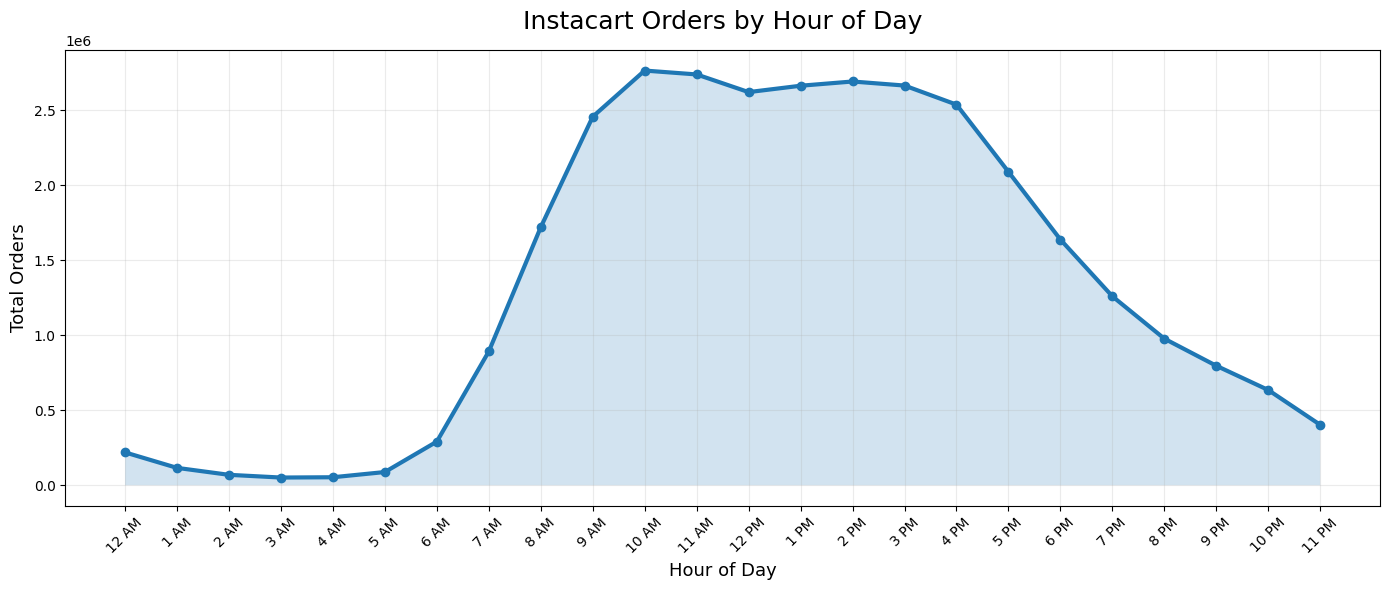

In [46]:
hourly_pd = hourly_orders.toPandas()

plt.figure(figsize=(14, 6))

plt.plot(
    hourly_pd["hour_label"],
    hourly_pd["total_orders"],
    marker="o",
    linewidth=3
)

plt.fill_between(
    hourly_pd["hour_label"],
    hourly_pd["total_orders"],
    alpha=0.2
)

plt.title(
    "Instacart Orders by Hour of Day",
    fontsize=18,
    pad=15
)

plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Total Orders", fontsize=13)

plt.xticks(rotation=45)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

#### Interpretation

Order activity rises sharply during the morning hours and peaks around midday and early afternoon. This suggests that users primarily place grocery orders during active daytime routines rather than late-night periods.

### Visualization 2: Most Popular Product Categories

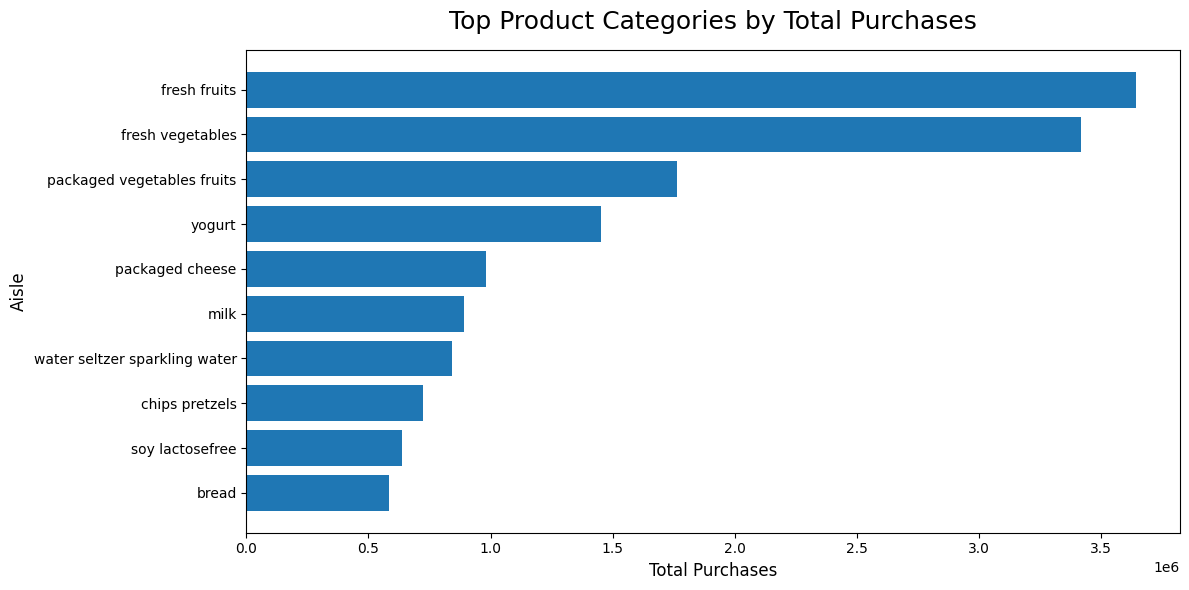

In [47]:
top_aisles_pd = top_aisles.limit(10).toPandas()

top_aisles_pd = top_aisles_pd.sort_values("total_purchases")

plt.figure(figsize=(12, 6))

plt.barh(
    top_aisles_pd["aisle"],
    top_aisles_pd["total_purchases"]
)

plt.title(
    "Top Product Categories by Total Purchases",
    fontsize=18,
    pad=15
)

plt.xlabel("Total Purchases", fontsize=12)
plt.ylabel("Aisle", fontsize=12)

plt.tight_layout()
plt.show()

#### Interpretation

Fresh produce categories dominate the Instacart ecosystem, with `fresh fruits` and `fresh vegetables` showing the highest purchase volumes. Dairy and packaged convenience products also represent major recurring purchasing categories.

### Visualization 3: Products with Highest Reorder Rates

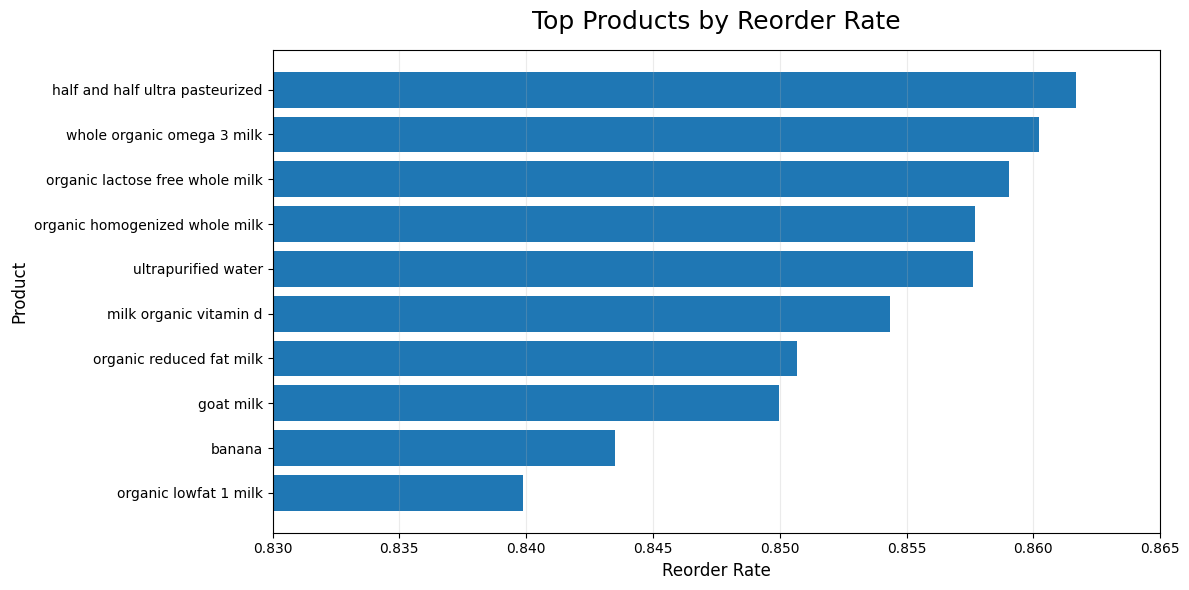

In [48]:
reordered_pd = most_reordered_products.limit(10).toPandas()
reordered_pd = reordered_pd.sort_values("reorder_rate")

plt.figure(figsize=(12, 6))

plt.barh(
    reordered_pd["normalized_product_name"],
    reordered_pd["reorder_rate"]
)

plt.title(
    "Top Products by Reorder Rate",
    fontsize=18,
    pad=15
)

plt.xlabel("Reorder Rate", fontsize=12)
plt.ylabel("Product", fontsize=12)

# Narrow x-axis range for visibility
plt.xlim(0.83, 0.865)

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

#### Interpretation

The products with the highest reorder rates are mostly recurring household staples such as milk-related products and bananas.
This suggests that reorder behavior is strongly connected to habitual consumption patterns rather than impulsive purchasing behavior.
High reorder rates also do not necessarily imply customer satisfaction or product preference alone. In many cases, users repeatedly purchase these products because they are essential items with stable weekly demand.
For example, a user may reorder bananas every week simply because they are part of a regular grocery routine, even if they would personally prefer a different fruit.
This creates an important analytical limitation: reorder frequency measures behavioral repetition, but not necessarily emotional preference or product quality perception.

### Visualization 4: Weekly Ordering Activity

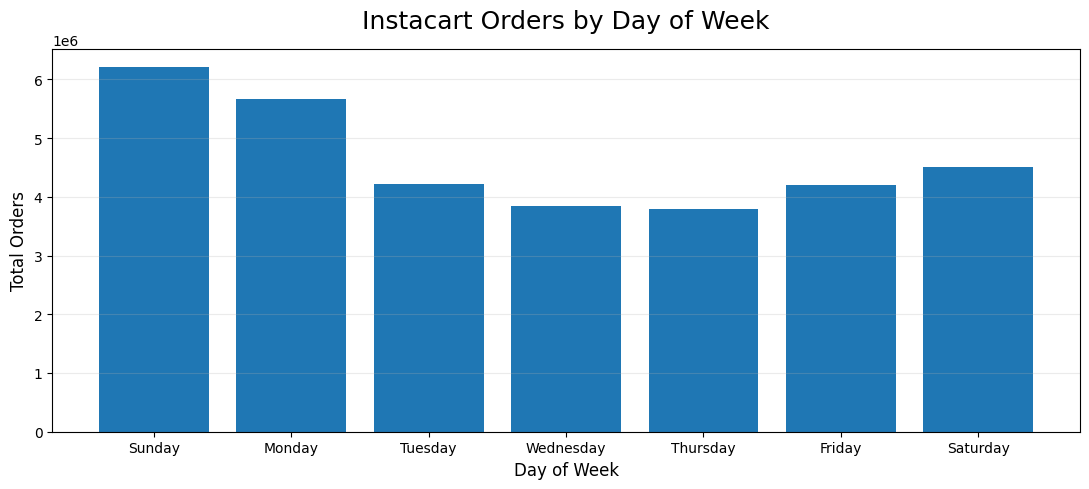

In [49]:
dow_pd = dow_activity.toPandas()

plt.figure(figsize=(11, 5))

plt.bar(
    dow_pd["day_name"],
    dow_pd["total_orders"]
)

plt.title(
    "Instacart Orders by Day of Week",
    fontsize=18,
    pad=15
)

plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

#### Interpretation

Weekly purchasing behavior is not uniformly distributed across the week.

Order activity is highest on Sunday and Monday, suggesting that many users place grocery orders during weekly household planning periods. Midweek activity is comparatively lower, while demand increases again toward the weekend.

### Visualization 5: Distribution of User Purchase Activity

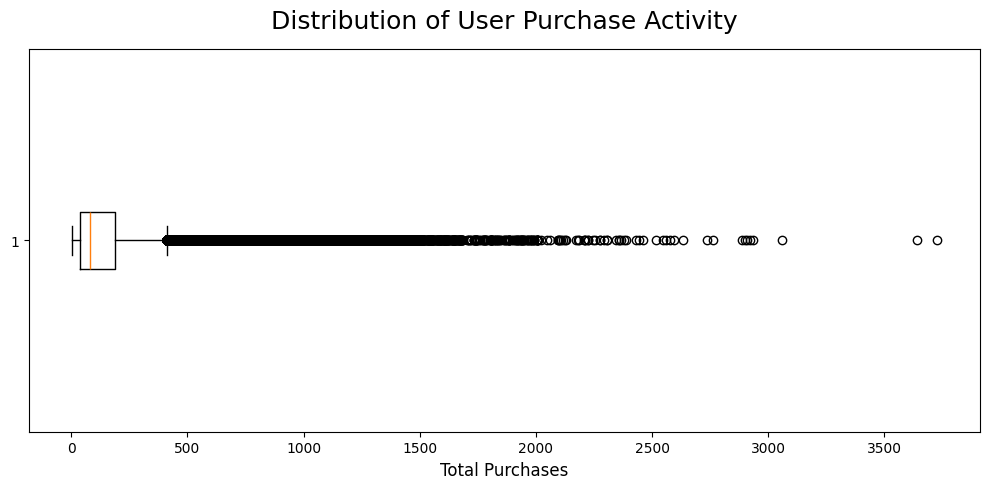

In [50]:
user_activity = (
    clean_prior_optimized
    .groupBy("user_id")
    .agg(count("*").alias("total_purchases"))
)

user_activity_pd = user_activity.toPandas()

plt.figure(figsize=(10, 5))

plt.boxplot(
    user_activity_pd["total_purchases"],
    vert=False
)

plt.title(
    "Distribution of User Purchase Activity",
    fontsize=18,
    pad=15
)

plt.xlabel("Total Purchases", fontsize=12)

plt.tight_layout()
plt.show()

#### Interpretation

The boxplot shows that user purchasing behavior is highly uneven across the platform.

Most users have moderate purchase activity, while a smaller group of users generates extremely large numbers of purchases and appears as strong outliers.

This indicates that a relatively small subset of highly active users contributes disproportionately to total transaction volume.

 ## Visualization 6: Semantic Product Subgroup Distribution

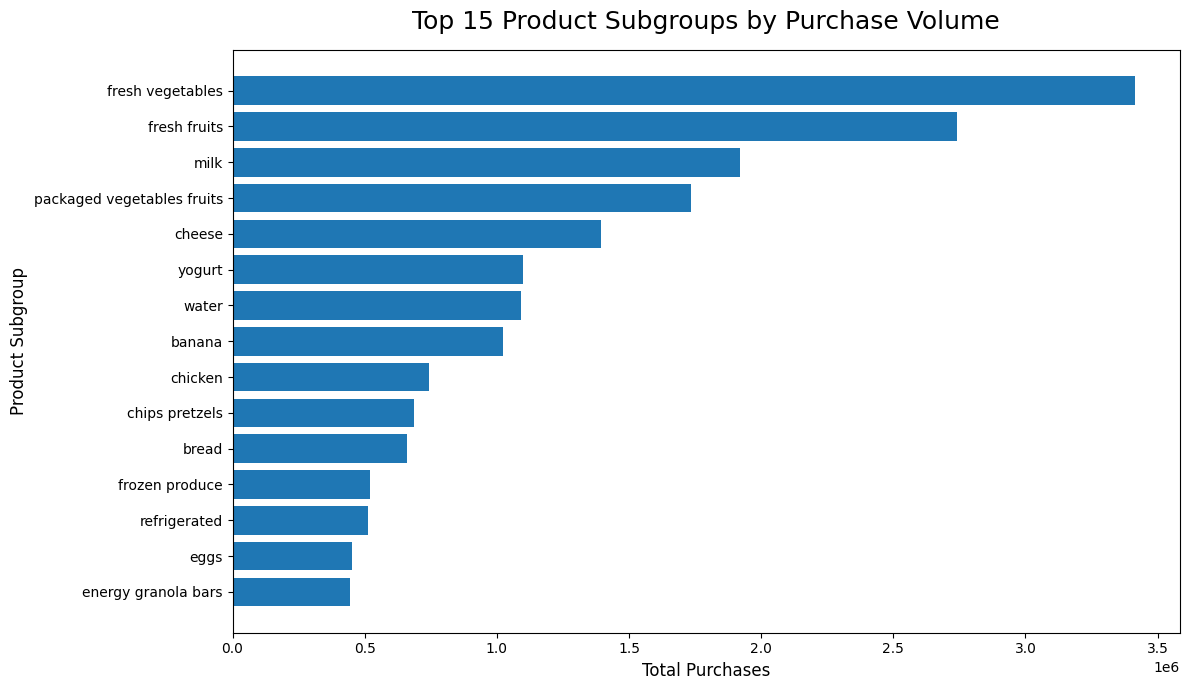

In [52]:
subgroup_pd = (
    clean_prior
    .filter(col("product_subgroup") != "other")
    .groupBy("product_subgroup")
    .count()
    .orderBy(desc("count"))
    .limit(15)
    .toPandas()
    .sort_values("count")
)
plt.figure(figsize=(12, 7))
plt.barh(subgroup_pd["product_subgroup"], subgroup_pd["count"])
plt.title("Top 15 Product Subgroups by Purchase Volume", fontsize=18, pad=15)
plt.xlabel("Total Purchases", fontsize=12)
plt.ylabel("Product Subgroup", fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation
Fresh vegetables and fresh fruits dominate purchasing volume, confirming that Instacart users primarily shop for perishable produce. Dairy-related subgroups (milk, cheese, yogurt) collectively form the second largest category. The subgroup distribution reflects habitual, routine grocery behavior rather than occasional or impulse purchasing patterns.

 ## Visualization 7: Reorder gap distribution

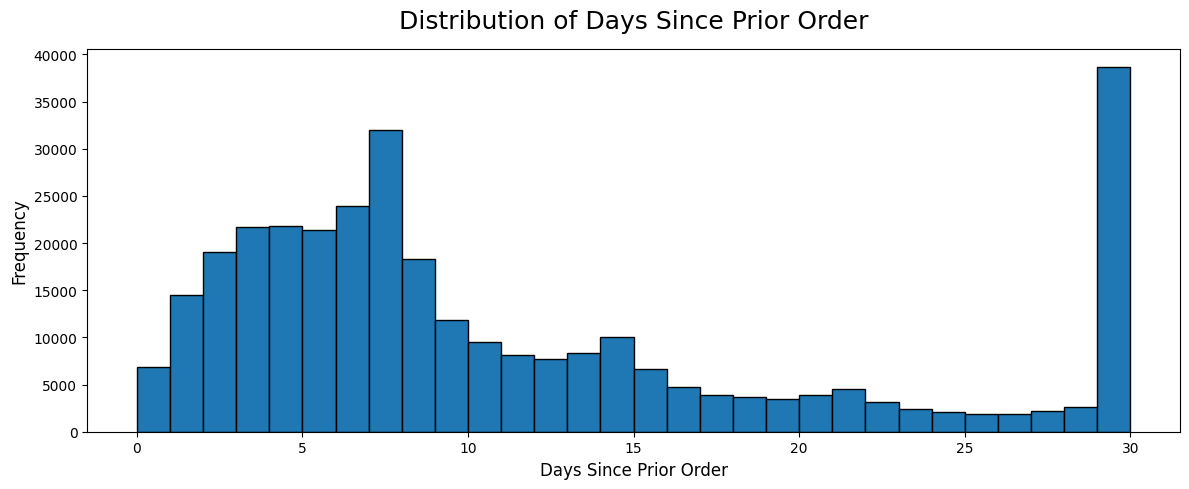

In [53]:
days_pd = (
    orders
    .filter(col("days_since_prior_order").isNotNull())
    .select("days_since_prior_order")
    .sample(fraction=0.1)  # մեծ dataset է, sample վերցնենք
    .toPandas()
)

plt.figure(figsize=(12, 5))
plt.hist(days_pd["days_since_prior_order"], bins=30, edgecolor="black")
plt.title("Distribution of Days Since Prior Order", fontsize=18, pad=15)
plt.xlabel("Days Since Prior Order", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation
The distribution reveals two notable behavioral patterns. First, ordering frequency peaks around 7 days, confirming a strong weekly shopping cycle among users. Second, there is a significant spike at exactly 30 days — this is a data artifact caused by the dataset capping days_since_prior_order at 30, meaning all orders placed 30 or more days apart are grouped into a single value. This creates an artificial spike and should be considered a data quality limitation when analyzing long-gap reorder behavior — users with 30, 45, or 60-day gaps are indistinguishable in this dataset.

## 7. Bias, Limitations, and Scalability Discussion

In [55]:
first_order_nulls = orders.filter(
    col("days_since_prior_order").isNull()
).count()
total_orders = orders.count()

print(f"First-order NULL rate: {round(first_order_nulls/total_orders*100, 2)}%")
print(f"Affected orders: {first_order_nulls} out of {total_orders}")

First-order NULL rate: 6.03%
Affected orders: 206209 out of 3421083


### How Data Quality Issues Could Affect the Results

Even though the dataset was mostly clean, several data quality issues could bias the analysis if handled incorrectly.
206,209 orders (6.03%) have NULL days_since_prior_order, corresponding to first-time orders. If these NULLs were replaced with 0, it would incorrectly suggest that 6.03% of all users reordered immediately, artificially inflating short-gap reorder metrics.
Additionally, days_since_prior_order is capped at 30 in the dataset. The value 30 appears 369,323 times — more than any other value — meaning users with 30, 45, or 60-day gaps are indistinguishable. This can bias temporal gap analysis and reorder frequency metrics.
Product name normalization improves grouping consistency, but removing punctuation and symbols may over-simplify names. For example, 2% Milk and Whole Milk both normalize toward the milk subgroup, losing product-level specificity.
Duplicate removal must be logic-based rather than blind. Blindly removing rows could accidentally remove real repeated purchases, affecting reorder statistics.
High reorder rates do not always indicate customer preference. Products like bananas or milk are reordered out of routine necessity rather than active preference, meaning reorder frequency measures behavioral repetition, not satisfaction.

### What Could Break if the Dataset Became 100x Larger?

If the dataset became much larger, some parts of the pipeline would become significantly more expensive.

- Shuffle operations during joins, aggregations, and window functions would increase heavily.
- Ranking products per user would require more sorting and memory usage.
- Caching very large datasets might no longer fit in memory.
- CSV files would become slower to process compared to formats like Parquet.
- Some partitions could become unbalanced if certain users have much more activity than others.

To improve scalability in the future, it would help to:
- store data in Parquet format,
- tune partitions more carefully,
- reduce unnecessary shuffles,
- and run the pipeline on a distributed Spark cluster instead of local mode.

# Conclusion

This project analyzed the Instacart Market Basket Analysis dataset using Apache Spark.

The workflow included:
- data quality validation,
- transactional data cleaning,
- multi-table joins,
- product name normalization,
- user-level behavioral analytics,
- Spark execution-plan analysis,
- and performance optimization.

Several meaningful purchasing patterns were identified, including recurring household purchasing behavior, temporal ordering trends, and highly active user outliers.

The optimized Spark pipeline significantly improved execution performance by reducing shuffle-heavy operations, broadcasting smaller tables, repartitioning strategically, and caching reusable intermediate datasets.

Overall, the project demonstrates how Spark can be used for scalable behavioral analytics while also highlighting the importance of careful data-quality reasoning and optimization-aware pipeline design.